In [2]:
from Scripts.Random_forest_nested import *
import matplotlib.pyplot as plt
import pickle 

In [5]:
df = pd.read_excel('../Data_preprocessing/all_time.xlsx', index_col=0)
X,y=df.loc[:,['scaled_nox','scaled_no2','scaled_formaldehyd','scaled_acetone','scaled_acetald',
    'scaled_bc', 'scaled_PM25','no2_street', 'nox_street', 'pm25_street', 'gestational_age', 'lrti_1y',
       'genetic_risk_score_asthma']],df.verificeret_18y

In [6]:
list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","Gestational age","LRTI","Asthma risk score"]

In [7]:
replace_dict=dict(zip(X.columns,list_parameters))
X=X.rename(columns=replace_dict)

In [8]:
param_distributions = {
    'n_estimators':           [300],
    'max_depth':              randint(2, 6),
    'min_samples_leaf':       randint(10, 30),
    'max_features':           [0.4, 0.5, 0.6, 'sqrt'],
    'max_samples':            [0.5, 0.6, 0.7, 0.8],
    # class_weight removed
}
dataframe =nested_cross_calibrated_rf(
    X, y,
    Number_CV=2,
    number_split=3,
    n_neighbors_imputer=25,
    param_distributions=param_distributions,
    calibration_method="isotonic")



Fold 1/6  AUC=0.604  BSS=+0.032  ICI=0.026
Fold 2/6  AUC=0.558  BSS=-0.016  ICI=0.056
Fold 3/6  AUC=0.504  BSS=-0.076  ICI=0.088
Fold 4/6  AUC=0.594  BSS=+0.007  ICI=0.047
Fold 5/6  AUC=0.410  BSS=-0.071  ICI=0.104
Fold 6/6  AUC=0.517  BSS=-0.024  ICI=0.068


In [9]:
with open("../Performence/results_rf_18y.pkl", "wb") as f:
    pickle.dump(dataframe, f)

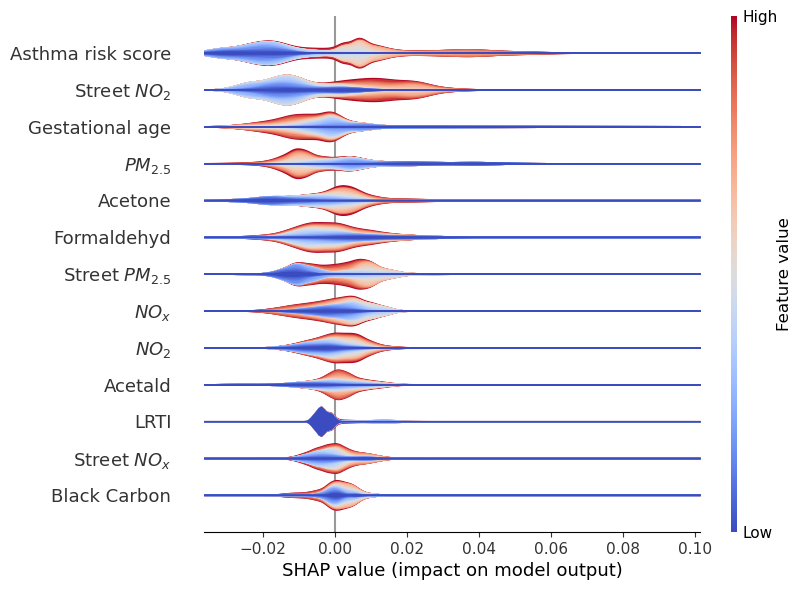

In [10]:

fig=shap.plots.violin(dataframe['shap_values_oof'],X ,plot_type="layered_violin",show=False)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})
# increase pad to push title further away


plt.savefig('../Plots/shap_18.png',dpi=300,bbox_inches='tight')
